
## Problem Statement
Analyze Netflix dataset to identify trends, patterns, and insights that can help in content strategy and decision making.
> Add blockquote



In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [20]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Data Quality Observations:

- Significant missing values in 'director' column (~30%), which may affect analysis involving creators
- Moderate missing values in 'cast' and 'country'
- Very few missing values in 'date_added', 'rating', and 'duration'

### Conclusion:
- Columns like 'director' may not be reliable for deep analysis
- Minor missing values can be safely removed without major data loss

In [21]:
df = df.dropna(subset=['country', 'date_added', 'rating'])

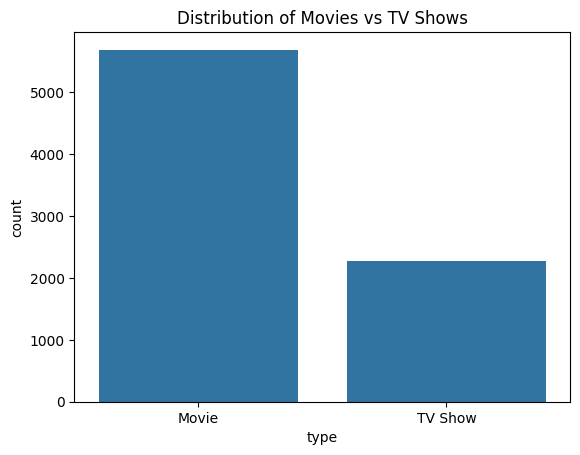

In [22]:
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.show()

### Insight:
- Movies dominate the platform compared to TV Shows.
- This suggests Netflix prioritizes movie content, possibly due to faster production and higher consumption rates.

### Business Impact:
- Investing more in movies may yield quicker returns.
- However, increasing TV show content could improve long-term user retention.

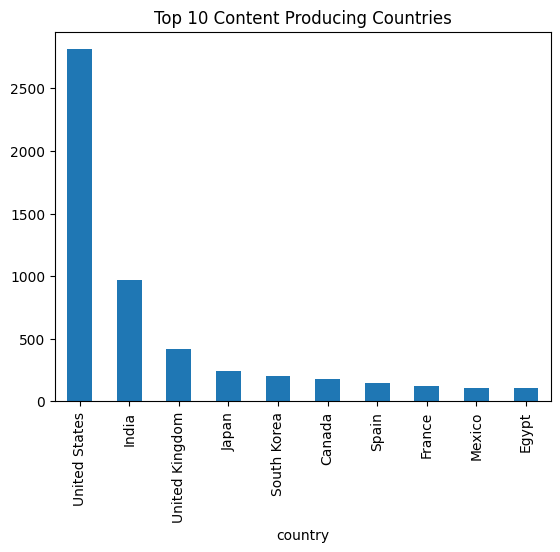

In [23]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.show()

### Insight:
- USA is the leading content producer, followed by India and the UK.
- Content production is concentrated in a few countries.

### Business Impact:
- Expanding production in emerging markets could diversify content.
- Localized content strategies may increase regional engagement.

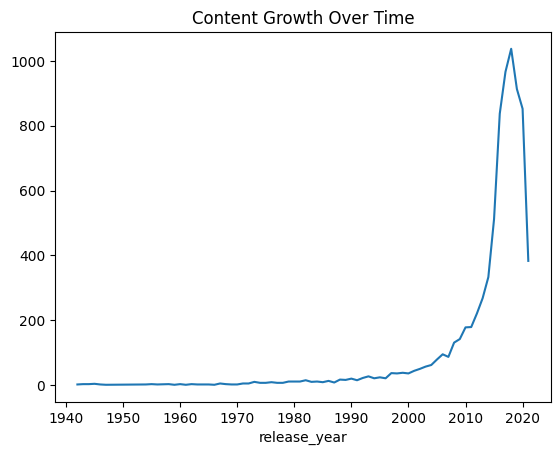

In [24]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Time")
plt.show()

### Insight:
- There is a sharp increase in content after 2015.
- Indicates rapid expansion of the platform.

### Business Impact:
- Growth phase suggests aggressive content acquisition strategy.
- Future focus may shift from quantity to quality optimization.

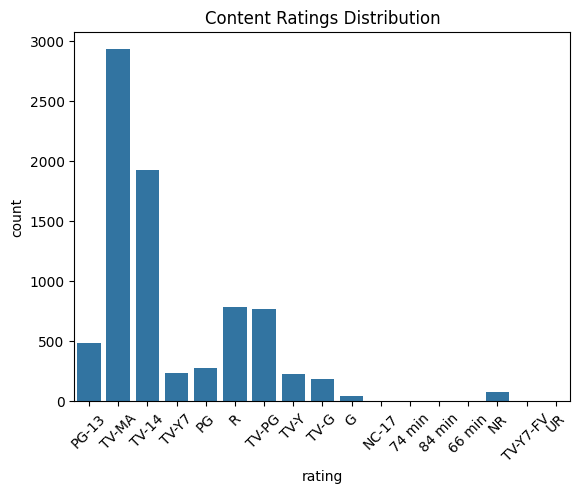

In [25]:
sns.countplot(x='rating', data=df)
plt.xticks(rotation=45)
plt.title("Content Ratings Distribution")
plt.show()

### Insight:
- Majority content falls under TV-MA (mature audience).
- Limited content is targeted toward children and family.

### Business Impact:
- Opportunity to expand into family-friendly content.
- Helps balance audience demographics.

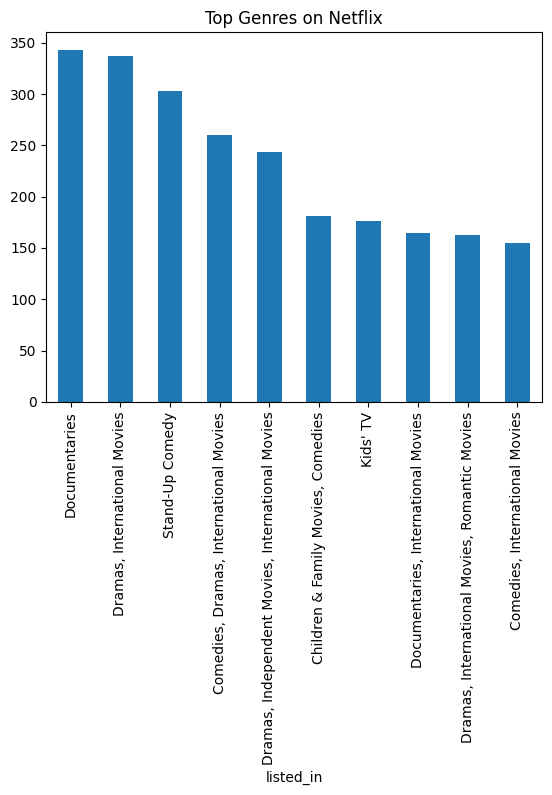

In [26]:
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()

### Insight:
- Documentaries and Drama and International Movies dominate the platform.
- Genre diversity exists but is skewed toward a few categories.

### Business Impact:
- Expanding underrepresented genres could attract niche audiences.
- Helps in content diversification strategy.

Mini Machine Learning

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

df_model = df[['type', 'rating']].dropna()

le = LabelEncoder()
df_model['type'] = le.fit_transform(df_model['type'])
df_model['rating'] = le.fit_transform(df_model['rating'])

X = df_model[['type']]
y = df_model['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.3854362837413685


### Model Insight:
A simple Decision Tree model was built to understand patterns between content type and rating.

### Business Relevance:
This demonstrates how machine learning can assist in content classification and recommendation systems.

## Conclusion that dataset is offering:

- Netflix content is dominated by movies rather than TV shows.
- Content production is concentrated in countries like the USA and India.
- Significant growth after 2015 indicates rapid platform expansion.
- Majority content is targeted toward mature audiences.
- Genre distribution shows dominance of drama and international content.

### Overall Insight:
This analysis demonstrates how data can be used to extract meaningful insights and support strategic decision-making in content platforms.